In [1]:
import requests
import json
import time
import pandas as pd

In [2]:
url = f"https://api.ravelry.com/projects/search.json"
uid, pw = "read-0ea4f9f35434b031dbcf2acbe301c226", "tlSskeRXLNybZBFYzE2gZaAL7K2Fh/eXPnLuHly9"

now to get finish crochet projects with photo

In [3]:
#https://www.ravelry.com/projects/search#craft=crochet&photo=yes&status=finished&finished-in=2025&country=united-states&sort=completed&view=thumbs
#91,779 / 4999 = 19
df_2025 = pd.DataFrame()

for page in range(1, 20):
    print(f"Fetching page {page}...")
    response = requests.get(url, auth=(uid, pw), params={
        "page": page,
        "page_size": 4999,
        "craft": "crochet",
        "photo": "yes",
        "country": "united-states",
        "finished-in":"2025",
        "status":"finished"
    })

    responselist = response.json()
    df_page = pd.json_normalize(responselist['projects'])
    df_2025 = pd.concat([df_2025, df_page], ignore_index=True)

    if page < 19:
        time.sleep(10)

print(f"Done. Total rows: {len(df_2025)}")

Fetching page 1...
Fetching page 2...
Fetching page 3...
Fetching page 4...
Fetching page 5...
Fetching page 6...
Fetching page 7...
Fetching page 8...
Fetching page 9...
Fetching page 10...
Fetching page 11...
Fetching page 12...
Fetching page 13...
Fetching page 14...
Fetching page 15...
Fetching page 16...
Fetching page 17...
Fetching page 18...


/tmp/ipykernel_211/2055462289.py:19: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_2025 = pd.concat([df_2025, df_page], ignore_index=True)


Fetching page 19...
Done. Total rows: 91785


In [6]:
df_2025.value_counts(['completed'])

,count
completed,
2025/01/01,665
2025/02/01,528
2025/09/01,502
2025/03/01,501
2025/12/01,498
...,...
2025/08/26,157
2025/10/02,155
2025/09/09,152


In [8]:
df_2025['completed'] = pd.to_datetime(df_2025['completed'])

In [10]:
monthly_counts = df_2025.groupby(
    df_2025['completed'].dt.to_period('M')
).size()

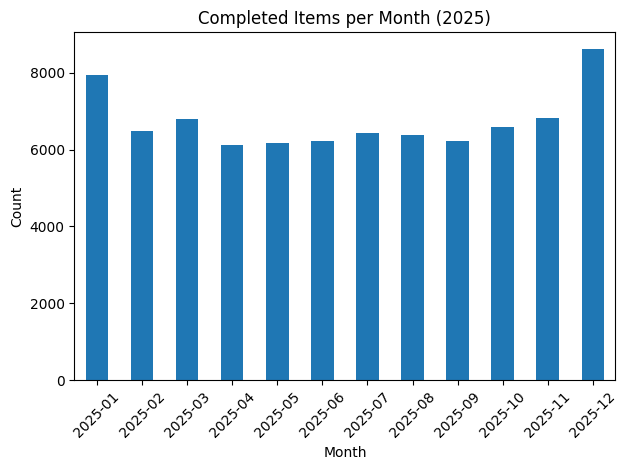

In [11]:
import matplotlib.pyplot as plt

monthly_counts.plot(kind='bar')

plt.xlabel("Month")
plt.ylabel("Count")
plt.title("Completed Items per Month (2025)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
#https://www.ravelry.com/projects/search#craft=crochet&photo=yes&status=finished&country=united-states&finished-in=2026&sort=completed&view=thumbs
#16,577 / 4999 = 4
df_2026 = pd.DataFrame()

for page in range(1, 5):
    print(f"Fetching page {page}...")
    response = requests.get(url, auth=(uid, pw), params={
        "page": page,
        "page_size": 4999,
        "craft": "crochet",
        "photo": "yes",
        "country": "united-states",
        "finished-in":"2026",
        "status":"finished"
    })

    responselist = response.json()
    df_page = pd.json_normalize(responselist['projects'])
    df_2026 = pd.concat([df_2026, df_page], ignore_index=True)

    if page < 4:
        time.sleep(10)

print(f"Done. Total rows: {len(df_2026)}")

Fetching page 1...
Fetching page 2...
Fetching page 3...
Fetching page 4...
Done. Total rows: 17132


In [14]:
df_mid_save = pd.concat([df_2026, df_2025], ignore_index=True)

In [15]:
print(len(df_mid_save))

108917


In [18]:
df_mid_save

,comments_count,completed,craft_id,created_at,favorites_count,id,made_for,made_for_user_id,name,pattern_id,...,first_photo.caption,first_photo.caption_html,first_photo.copyright_holder,first_photo.aspect_ratio,user.id,user.username,user.tiny_photo_url,user.small_photo_url,user.photo_url,user.profile_country_code
0,14,2026/02/02,1.0,2026/01/31 22:58:43 -0500,101,38461166,me!,NaN,Red Tassel ICE Melter,7500627.0,...,None,None,None,1.324427,502327,rockfield,https://avatars-d.ravelrycache.com/rockfield/1...,https://avatars-d.ravelrycache.com/rockfield/1...,https://avatars-d.ravelrycache.com/rockfield/1...,US
1,5,2026/01/09,1.0,2025/12/14 13:26:32 -0500,122,38012743,Myself,NaN,Blooming Bomber Jacket,872383.0,...,None,None,None,0.750625,8863243,ImTwistedRibKnits,https://avatars-d.ravelrycache.com/ImTwistedRi...,https://avatars-d.ravelrycache.com/ImTwistedRi...,https://avatars-d.ravelrycache.com/ImTwistedRi...,US
2,0,2026/02/20,1.0,2026/03/14 05:58:10 -0400,8,38778711,,NaN,Whimsical Hat,NaN,...,None,None,None,0.746250,2057428,wyllen-praett,https://avatars-d.ravelrycache.com/wyllen-prae...,https://avatars-d.ravelrycache.com/wyllen-prae...,https://avatars-d.ravelrycache.com/wyllen-prae...,US
3,42,2026/03/01,1.0,2026/01/12 18:54:01 -0500,108,38288488,,NaN,Marguerite Blanket,898290.0,...,Partial view of afghan. It is a coincidence t...,Partial view of afghan. It is a coincidence t...,None,0.750000,1905024,Purlificknitter,https://avatars-d.ravelrycache.com/Purlifickni...,https://avatars-d.ravelrycache.com/Purlifickni...,https://avatars-d.ravelrycache.com/Purlifickni...,US
4,1,2026/01/24,1.0,2026/01/21 12:02:06 -0500,31,38364039,,NaN,Melt the ICE (Crochet Version),7496458.0,...,None,None,None,0.746250,12258230,ssward,https://avatars-d.ravelrycache.com/ssward/1122...,https://avatars-d.ravelrycache.com/ssward/1122...,https://avatars-d.ravelrycache.com/ssward/1122...,US
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108912,0,2025-12-18 00:00:00,1.0,2026/03/12 22:00:28 -0400,0,38770893,Kaelyn,NaN,Fairy Mermaid,NaN,...,None,None,None,0.750000,9428380,warrenfamily1699,https://avatars-d.ravelrycache.com/warrenfamil...,https://avatars-d.ravelrycache.com/warrenfamil...,https://avatars-d.ravelrycache.com/warrenfamil...,US
108913,0,2025-12-15 00:00:00,1.0,2026/03/13 12:19:52 -0400,0,38774057,,NaN,neck scarf,7385763.0,...,None,None,None,1.000000,20653,cawingcrow,https://avatars-d.ravelrycache.com/cawingcrow/...,https://avatars-d.ravelrycache.com/cawingcrow/...,https://avatars-d.ravelrycache.com/cawingcrow/...,US
108914,0,2025-12-29 00:00:00,1.0,2026/03/13 16:44:46 -0400,0,38775702,Ida,NaN,Ida's Emergency Hat,NaN,...,None,None,None,0.750000,3288651,beck-a-la,https://avatars-d.ravelrycache.com/beck-a-la/8...,https://avatars-d.ravelrycache.com/beck-a-la/8...,https://avatars-d.ravelrycache.com/beck-a-la/8...,US
108915,0,2025-03-01 00:00:00,1.0,2026/03/13 18:31:17 -0400,0,38776325,,NaN,Shell Stitch Fingerless Gloves,NaN,...,None,None,None,0.750000,755753,Epstarr,https://avatars-d.ravelrycache.com/Epstarr/112...,https://avatars-d.ravelrycache.com/Epstarr/112...,https://avatars-d.ravelrycache.com/Epstarr/112...,US


In [19]:
df_mid_save.to_csv("progress_save_2025_2026_108315.csv")

In [12]:
df_2025['id']

,id
0,36749603
1,36224139
2,35117754
3,32923893
4,36754945
...,...
91780,38770893
91781,38774057
91782,38775702
91783,38776325


seems like in getting rate limited at this point, try again later

In [ ]:
#https://www.ravelry.com/projects/search#craft=crochet&happiness=3&weight=worsted&photo=yes&status=finished&finished-in=1&country=united-states&sort=completed&view=thumbs
#51,302 / 4999= 11

df_3_1 = pd.DataFrame()

for page in range(1, 12):
    print(f"Fetching page {page}...")
    response = requests.get(url, auth=(uid, pw), params={
        "page": page,
        "page_size": 4999,
        "craft": "crochet",
        "photo": "yes",
        "country": "united-states",
        "happiness": "3",
        "finished-in":"1",
        "status":"finished",
        "weight":"worsted"
    })

    responselist = response.json()
    df_page = pd.json_normalize(responselist['projects'])
    df_3_1 = pd.concat([df_3_1, df_page], ignore_index=True)
    print(f"  → {len(df_page)} records (total so far: {len(df_3_1)})")

    if page < 11:
        time.sleep(10)

print(f"Done. Total rows: {len(df_3_1)}")


Fetching page 1...
  → 4999 records (total so far: 4999)
Fetching page 2...
  → 4999 records (total so far: 9998)
Fetching page 3...
  → 4999 records (total so far: 14997)
Fetching page 4...
  → 4999 records (total so far: 19996)
Fetching page 5...
  → 4999 records (total so far: 24995)
Fetching page 6...
  → 4999 records (total so far: 29994)
Fetching page 7...
  → 4999 records (total so far: 34993)
Fetching page 8...


/tmp/ipykernel_183/228255521.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_3_1 = pd.concat([df_3_1, df_page], ignore_index=True)


  → 4999 records (total so far: 39992)
Fetching page 9...
  → 4999 records (total so far: 44991)
Fetching page 10...
  → 4999 records (total so far: 49990)
Fetching page 11...
  → 1271 records (total so far: 51261)
Done. Total rows: 51261


In [ ]:
responselist['paginator']

{'page_count': 11,
 'page': 11,
 'page_size': 4999,
 'results': 51261,
 'last_page': 11}

In [ ]:
# https://www.ravelry.com/projects/search#craft=crochet&happiness=3&weight=-worsted&photo=yes&status=finished&meterage-in=0-150%7C150-300%7C300-450%7C450-600%7C600-750%7C750-900%7C900-1200%7C1200-1500&finished-in=1&country=united-states&sort=completed&view=thumbs
#99,690 / 4999= 20

df_3_2 = pd.DataFrame()

for page in range(1, 21):
    print(f"Fetching page {page}...")
    response = requests.get(url, auth=(uid, pw), params={
        "page": page,
        "page_size": 4999,
        "craft": "crochet",
        "photo": "yes",
        "country": "united-states",
        "happiness": "3",
        "finished-in":"1",
        "status":"finished",
        "weight":"-worsted",
        "meterage-in":"0-150|150-300|300-450|450-600|600-750|750-900|900-1200|1200-1500"
    })

    responselist = response.json()
    df_page = pd.json_normalize(responselist['projects'])
    df_3_2  = pd.concat([df_3_2, df_page], ignore_index=True)

    print(f"  → {len(df_page)} records (total so far: {len(df_3_2)})")

    if page < 20:
        time.sleep(10)

print(f"Done. Total rows: {len(df_3_2)}")

Fetching page 1...
Fetching page 2...
Fetching page 3...
Fetching page 4...
Fetching page 5...
Fetching page 6...
Fetching page 7...
Fetching page 8...
Fetching page 9...
Fetching page 10...
Fetching page 11...
Fetching page 12...
Fetching page 13...
Fetching page 14...
Fetching page 15...
Fetching page 16...
Fetching page 17...


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [ ]:
df_3_3 = pd.DataFrame()

for page in range(17, 21):
    print(f"Fetching page {page}...")
    response = requests.get(url, auth=(uid, pw), params={
        "page": page,
        "page_size": 4999,
        "craft": "crochet",
        "photo": "yes",
        "country": "united-states",
        "happiness": "3",
        "finished-in":"1",
        "status":"finished",
        "weight":"-worsted",
        "meterage-in":"0-150|150-300|300-450|450-600|600-750|750-900|900-1200|1200-1500"
    })

    responselist = response.json()
    df_page = pd.json_normalize(responselist['projects'])
    df_3_3  = pd.concat([df_3_3, df_page], ignore_index=True)

    print(f"  → {len(df_page)} records (total so far: {len(df_3_3)})")

    if page < 20:
        time.sleep(10)

print(f"Done. Total rows: {len(df_3_3)}")
print(f"Done. Total rows: {len(df_3_3)}")

Fetching page 17...
  → 4999 records (total so far: 4999)
Fetching page 18...
  → 4999 records (total so far: 9998)
Fetching page 19...
  → 4999 records (total so far: 14997)
Fetching page 20...
  → 4627 records (total so far: 19624)
Done. Total rows: 19624
Done. Total rows: 19624


/tmp/ipykernel_183/1029233589.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_3_3  = pd.concat([df_3_3, df_page], ignore_index=True)


In [ ]:
df_  = pd.concat([df_3_1, df_3_2], ignore_index=True)
df_  = pd.concat([df_, df_3_3], ignore_index=True)

In [ ]:
len(df_)

150869

In [ ]:
df_.to_csv("progess_save_150869.csv")

In [ ]:
#https://www.ravelry.com/projects/search#craft=crochet&happiness=3&weight=-worsted&photo=yes&status=finished&meterage-in=-0-150%2B-150-300%2B-300-450%2B-450-600%2B-600-750%2B-750-900%2B-900-1200%2B-1200-1500&finished-in=1&colors=1%7C2%7C4%7C3%7C6%7C5&country=united-states&sort=completed&view=thumbs
# 51,415 / 4999 = 11
df_4= pd.DataFrame()

for page in range(1, 12):
    print(f"Fetching page {page}...")
    response = requests.get(url, auth=(uid, pw), params={
        "page": page,
        "page_size": 4999,
        "craft": "crochet",
        "photo": "yes",
        "country": "united-states",
        "happiness": "3",
        "finished-in":"1",
        "status":"finished",
        "weight": "-worsted",
        "meterage-in": "-0-150+-150-300+-300-450+-450-600+-600-750+-750-900+-900-1200+-1200-1500",
        "colors": "1|2|4|3|6|5"

    })

    responselist = response.json()
    df_page = pd.json_normalize(responselist['projects'])
    df_4  = pd.concat([df_4, df_page], ignore_index=True)
    print(f"  → {len(df_page)} records (total so far: {len(df_4)})")

    if page < 11:
        time.sleep(10)

print(f"Done. Total rows: {len(df_4)}")

Fetching page 1...
  → 4999 records (total so far: 4999)
Fetching page 2...
  → 4999 records (total so far: 9998)
Fetching page 3...
  → 4999 records (total so far: 14997)
Fetching page 4...
  → 4999 records (total so far: 19996)
Fetching page 5...
  → 4999 records (total so far: 24995)
Fetching page 6...
  → 4999 records (total so far: 29994)
Fetching page 7...
  → 4999 records (total so far: 34993)
Fetching page 8...
  → 4999 records (total so far: 39992)
Fetching page 9...
  → 4999 records (total so far: 44991)
Fetching page 10...
  → 4999 records (total so far: 49990)
Fetching page 11...
  → 1381 records (total so far: 51371)
Done. Total rows: 51371


In [ ]:
len(df_4)
len(df_)

150869

In [ ]:
responselist['paginator']

{'page_count': 11,
 'page': 11,
 'page_size': 4999,
 'results': 51371,
 'last_page': 11}

In [ ]:
df_  = pd.concat([df_, df_4], ignore_index=True)

In [ ]:
len(df_)
df_.to_csv("progess_save_202240.csv")

In [ ]:
#https://www.ravelry.com/projects/search#craft=crochet&happiness=3&weight=-worsted&photo=yes&status=finished&meterage-in=-0-150%2B-150-300%2B-300-450%2B-450-600%2B-600-750%2B-750-900%2B-900-1200%2B-1200-1500&hooks=5.0mm&finished-in=1&colors=-1%2B-2%2B-4%2B-3%2B-6%2B-5&country=united-states&sort=completed&view=thumbs
# 17,451 matches / 4999 =4

df_5= pd.DataFrame()

for page in range(1, 5):
    print(f"Fetching page {page}...")
    response = requests.get(url, auth=(uid, pw), params={
        "page": page,
        "page_size": 4999,
        "craft": "crochet",
        "photo": "yes",
        "country": "united-states",
        "happiness": "3",
        "finished-in":"1",
        "status":"finished",
        "weight": "-worsted",
        "meterage-in": "-0-150+-150-300+-300-450+-450-600+-600-750+-750-900+-900-1200+-1200-1500",
        "colors": "-1+-2+-4+-3+-6+-5",
        "hooks": "5.0mm"
    })

    responselist = response.json()
    df_page = pd.json_normalize(responselist['projects'])
    df_5  = pd.concat([df_5, df_page], ignore_index=True)
    print(f"  → {len(df_page)} records (total so far: {len(df_5)})")

    if page < 4:
        time.sleep(10)

print(f"Done. Total rows: {len(df_5)}")


Fetching page 1...
  → 4999 records (total so far: 4999)
Fetching page 2...
  → 4999 records (total so far: 9998)
Fetching page 3...


/tmp/ipykernel_183/1731511764.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_5  = pd.concat([df_5, df_page], ignore_index=True)


  → 4999 records (total so far: 14997)
Fetching page 4...
  → 2443 records (total so far: 17440)
Done. Total rows: 17440


In [ ]:
# https://www.ravelry.com/projects/search#craft=crochet&happiness=3&weight=-worsted&photo=yes&status=finished&meterage-in=-0-150%2B-150-300%2B-300-450%2B-450-600%2B-600-750%2B-750-900%2B-900-1200%2B-1200-1500&hooks=-5.0mm&finished-in=1&colors=-1%2B-2%2B-4%2B-3%2B-6%2B-5&country=united-states&language=en&sort=completed&view=thumbs
# 40,111 matches / 4999 = 9

df_6= pd.DataFrame()

for page in range(1, 10):
    print(f"Fetching page {page}...")
    response = requests.get(url, auth=(uid, pw), params={
        "page": page,
        "page_size": 4999,
        "craft": "crochet",
        "photo": "yes",
        "country": "united-states",
        "happiness": "3",
        "finished-in":"1",
        "status":"finished",
        "weight": "-worsted",
        "meterage-in": "-0-150+-150-300+-300-450+-450-600+-600-750+-750-900+-900-1200+-1200-1500",
        "colors": "-1+-2+-4+-3+-6+-5",
        "hooks": "-5.0mm",
        "language": "en"
    })

    responselist = response.json()
    df_page = pd.json_normalize(responselist['projects'])
    df_6  = pd.concat([df_6, df_page], ignore_index=True)
    print(f"  → {len(df_page)} records (total so far: {len(df_6)})")

    if page < 9:
        time.sleep(10)

print(f"Done. Total rows: {len(df_6)}")


Fetching page 1...
  → 4999 records (total so far: 4999)
Fetching page 2...


/tmp/ipykernel_183/2237809466.py:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_6  = pd.concat([df_6, df_page], ignore_index=True)


  → 4999 records (total so far: 9998)
Fetching page 3...
  → 4999 records (total so far: 14997)
Fetching page 4...
  → 4999 records (total so far: 19996)
Fetching page 5...
  → 4999 records (total so far: 24995)
Fetching page 6...
  → 4999 records (total so far: 29994)
Fetching page 7...
  → 4999 records (total so far: 34993)
Fetching page 8...


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [ ]:
df_6_1= pd.DataFrame()

for page in range(8, 10):
    print(f"Fetching page {page}...")
    response = requests.get(url, auth=(uid, pw), params={
        "page": page,
        "page_size": 4999,
        "craft": "crochet",
        "photo": "yes",
        "country": "united-states",
        "happiness": "3",
        "finished-in":"1",
        "status":"finished",
        "weight": "-worsted",
        "meterage-in": "-0-150+-150-300+-300-450+-450-600+-600-750+-750-900+-900-1200+-1200-1500",
        "colors": "-1+-2+-4+-3+-6+-5",
        "hooks": "-5.0mm",
        "language": "en"
    })

    responselist = response.json()
    df_page = pd.json_normalize(responselist['projects'])
    df_6_1  = pd.concat([df_6_1, df_page], ignore_index=True)
    print(f"  → {len(df_page)} records (total so far: {len(df_6_1)})")

    if page < 9:
        time.sleep(10)

print(f"Done. Total rows: {len(df_6_1)}")


Fetching page 8...
  → 4999 records (total so far: 4999)
Fetching page 9...
  → 85 records (total so far: 5084)
Done. Total rows: 5084


/tmp/ipykernel_183/596339003.py:23: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_6_1  = pd.concat([df_6_1, df_page], ignore_index=True)


In [ ]:
df_  = pd.concat([df_, df_5], ignore_index=True)
df_  = pd.concat([df_, df_6], ignore_index=True)
df_  = pd.concat([df_, df_6_1], ignore_index=True)
len(df_)

259757

In [ ]:
df_.to_csv("progess_save_259757.csv")

In [ ]:
# https://www.ravelry.com/projects/search#craft=crochet&happiness=3&weight=-worsted&photo=yes&status=finished&meterage-in=-0-150%2B-150-300%2B-300-450%2B-450-600%2B-600-750%2B-750-900%2B-900-1200%2B-1200-1500&hooks=-5.0mm&finished-in=1&colors=-1%2B-2%2B-4%2B-3%2B-6%2B-5&language=-en&country=united-states&sort=completed&view=thumbs
# 96,936 matches
df_7 = pd.DataFrame()

# Preflight
response = requests.get(url, auth=(uid, pw), params={
    "page": 1,
    "page_size": 4999,
    "craft": "crochet",
    "photo": "yes",
    "country": "united-states",
    "happiness": "3",
    "finished-in": "1",
    "status": "finished",
    "weight": "-worsted",
    "meterage-in": "-0-150+-150-300+-300-450+-450-600+-600-750+-750-900+-900-1200+-1200-1500",
    "colors": "-1+-2+-4+-3+-6+-5",
    "hooks": "-5.0mm",
    "language": "-en"
})
last_page = response.json()['paginator']['last_page']
print(f"Total pages: {last_page}")

for page in range(1, last_page + 1):
    print(f"Fetching page {page}/{last_page}...")

    retry_delay = 60
    while True:
        response = requests.get(url, auth=(uid, pw), params={
            "page": page,
            "page_size": 4999,
            "craft": "crochet",
            "photo": "yes",
            "country": "united-states",
            "happiness": "3",
            "finished-in": "1",
            "status": "finished",
            "weight": "-worsted",
            "meterage-in": "-0-150+-150-300+-300-450+-450-600+-600-750+-750-900+-900-1200+-1200-1500",
            "colors": "-1+-2+-4+-3+-6+-5",
            "hooks": "-5.0mm",
            "language": "-en"
        })

        try:
            responselist = response.json()
            break
        except requests.exceptions.JSONDecodeError:
            print(f"  Empty response (status: {response.status_code}), retrying in {retry_delay}s...")
            time.sleep(retry_delay)
            retry_delay = min(retry_delay * 2, 300)

    df_page = pd.json_normalize(responselist['projects'])
    df_7 = pd.concat([df_7, df_page], ignore_index=True)
    print(f"  → {len(df_page)} records (total: {len(df_7)})")

    if page < last_page:
        time.sleep(60)

print(f"Done. Total rows: {len(df_7)}")


Total pages: 20
Fetching page 1/20...
  → 4999 records (total: 4999)
Fetching page 2/20...


/tmp/ipykernel_183/3398296796.py:54: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_7 = pd.concat([df_7, df_page], ignore_index=True)


  → 4999 records (total: 9998)
Fetching page 3/20...
  → 4999 records (total: 14997)
Fetching page 4/20...
  → 4999 records (total: 19996)
Fetching page 5/20...
  → 4999 records (total: 24995)
Fetching page 6/20...
  Empty response (status: 504), retrying in 60s...
  → 4999 records (total: 29994)
Fetching page 7/20...
  → 4999 records (total: 34993)
Fetching page 8/20...
  → 4999 records (total: 39992)
Fetching page 9/20...
  → 4999 records (total: 44991)
Fetching page 10/20...
  → 4999 records (total: 49990)
Fetching page 11/20...
  → 4999 records (total: 54989)
Fetching page 12/20...
  → 4999 records (total: 59988)
Fetching page 13/20...
  → 4999 records (total: 64987)
Fetching page 14/20...
  → 4999 records (total: 69986)
Fetching page 15/20...
  → 4999 records (total: 74985)
Fetching page 16/20...
  → 4999 records (total: 79984)
Fetching page 17/20...
  → 4999 records (total: 84983)
Fetching page 18/20...
  → 4999 records (total: 89982)
Fetching page 19/20...
  → 4999 records (tota

In [ ]:

print(len(df_))
len(df_7)

259757


96873

In [ ]:
df_  = pd.concat([df_, df_7], ignore_index=True)
len(df_7)

96873

In [37]:
len(df_)

453503

In [38]:
df_.to_csv("progress_save_453503.csv")